In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("classic")


In [2]:
agrupacion_horas = pd.read_csv("../data/agrupacion_horas.csv", sep=None, engine='python')
cierre_caja      = pd.read_csv("../data/cierre_caja.csv",      sep=None, engine='python')
compras_tpv      = pd.read_csv("../data/compras_tpv.csv",      sep=None, engine='python')
ventas_glovo     = pd.read_csv("../data/ventas_glovo.csv",     sep=None, engine='python')
compras_art      = pd.read_csv("../data/compras_articulos.csv",     sep=None, engine='python')

# Limpiar BOM y espacios en nombres de columnas
for df in [cierre_caja, compras_tpv, ventas_glovo]:
    df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

# Copias de trabajo
horas  = agrupacion_horas.copy()
cierre = cierre_caja.copy()
ventas = compras_tpv.copy()
glovo  = ventas_glovo.copy()
compras=compras_art.copy()

print('Datos cargados correctamente')

Datos cargados correctamente


In [3]:
display(compras)

,ProductID,Name,Description,OrderCode,Brand,Size,Qty,Value,Discount,ValueIncVAT,ValueExcVAT,TotCost,Margin,MarginPerc
0,2160051,Doble Cara A4 Color,Doble Cara A4 Color,NaN,NaN,NaN,513,410.40,14.74,395.66,360.60,25.650,334.95,0.92887
1,2156338,10 Colores Mickey,10 Colores Mickey,NaN,NaN,NaN,1,5.89,0.00,5.89,4.87,3.460,1.41,0.28953
2,2154194,1200 Amarillo C-005,1200 Amarillo C-005,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
3,2154182,1200 Azul C-010,1200 Azul C-010,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
4,2154202,1200 Naranja Fluo C-066,1200 Naranja Fluo C-066,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,2153298,Velocity HB 0.5,Velocity HB 0.5,NaN,NaN,NaN,5,7.75,0.00,7.75,6.40,2.300,4.10,0.64063
858,2153282,Velocity HB 0.7,Velocity HB 0.7,NaN,NaN,NaN,5,7.75,0.00,7.75,6.40,2.800,3.60,0.56250
859,2155691,Verde Claro Fun 1.6,Verde Claro Fun 1.6,NaN,NaN,NaN,7,4.90,0.00,4.90,4.06,1.379,2.68,0.66034
860,2155700,Violeta Fun 1.6,Violeta Fun 1.6,NaN,NaN,NaN,10,7.00,0.00,7.00,5.80,1.970,3.83,0.66034


In [4]:
df1=compras.copy()
df1=df1.drop(columns=["OrderCode", "Brand", "Size", "Description"])
display(df1)


,ProductID,Name,Qty,Value,Discount,ValueIncVAT,ValueExcVAT,TotCost,Margin,MarginPerc
0,2160051,Doble Cara A4 Color,513,410.40,14.74,395.66,360.60,25.650,334.95,0.92887
1,2156338,10 Colores Mickey,1,5.89,0.00,5.89,4.87,3.460,1.41,0.28953
2,2154194,1200 Amarillo C-005,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
3,2154182,1200 Azul C-010,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
4,2154202,1200 Naranja Fluo C-066,2,2.40,0.00,2.40,1.98,0.920,1.06,0.53535
...,...,...,...,...,...,...,...,...,...,...
857,2153298,Velocity HB 0.5,5,7.75,0.00,7.75,6.40,2.300,4.10,0.64063
858,2153282,Velocity HB 0.7,5,7.75,0.00,7.75,6.40,2.800,3.60,0.56250
859,2155691,Verde Claro Fun 1.6,7,4.90,0.00,4.90,4.06,1.379,2.68,0.66034
860,2155700,Violeta Fun 1.6,10,7.00,0.00,7.00,5.80,1.970,3.83,0.66034


In [5]:
df1.describe()

,ProductID,Qty,Value,Discount,ValueIncVAT,ValueExcVAT,TotCost,Margin,MarginPerc
count,8.620000e+02,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000
mean,2.167153e+06,30.023202,19.945986,0.177227,19.768759,17.095777,7.529212,9.566624,0.457295
std,3.358205e+04,368.139090,82.864827,2.506610,81.760535,75.328813,24.541968,55.909515,0.184815
min,2.148553e+06,0.000000,0.000000,-12.600000,0.000000,0.000000,0.000000,-9.290000,-0.222220
25%,2.152792e+06,1.000000,3.050000,0.000000,3.100000,2.640000,1.252500,1.090000,0.354997
50%,2.156304e+06,2.000000,6.300000,0.000000,6.300000,5.335000,2.805000,2.220000,0.444225
75%,2.160608e+06,5.000000,14.137500,0.000000,14.164925,11.777500,6.595000,4.867500,0.548188
max,2.337911e+06,8553.000000,1525.000000,45.000000,1510.060000,1400.100000,427.650000,1095.100000,1.000000


Text(0.5, 1.0, 'Histograma de Margen (%)')

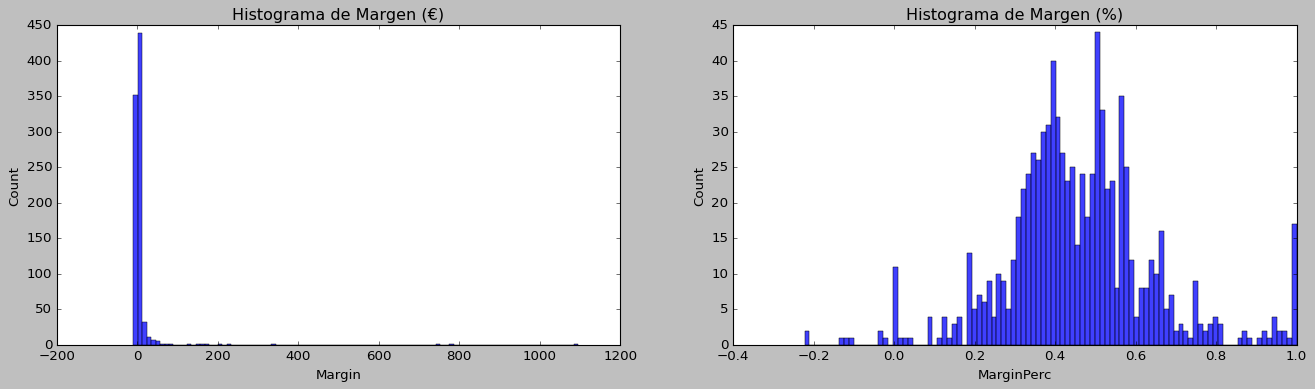

In [6]:
fig,ax=(plt.subplots(1,2,figsize=(20,5)))

sns.histplot(data=df1.Margin, bins=100, ax=ax[0])
ax[0].set_title("Histograma de Margen (€)")
sns.histplot(data=df1.MarginPerc, bins=100, ax=ax[1])
ax[1].set_title("Histograma de Margen (%)")

Text(0.5, 1.0, 'Histograma de Margen (%)')

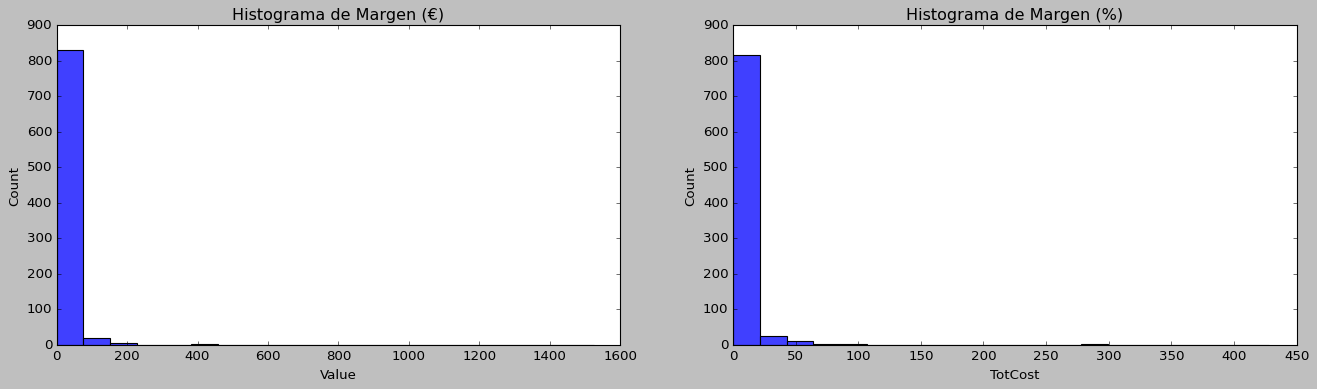

In [7]:
fig,ax=(plt.subplots(1,2,figsize=(20,5)))

sns.histplot(data=df1.Value, bins=20, ax=ax[0])
ax[0].set_title("Histograma de Margen (€)")
sns.histplot(data=df1.TotCost, bins=20, ax=ax[1])
ax[1].set_title("Histograma de Margen (%)")

## Hipótesis 1
 **Los 5 productos más vendidos por volumen son también los que mayor margen absoluto aportan al negocio.."**

---

### Contexto del análisis

Para contrastar esta hipótesis se parte del dataset compras_articulos.csv, que recoge las líneas de compra de artículos del negocio. Tras la limpieza inicial, el dataset de trabajo (df1) contiene **862 registros** y **10 variables** relevantes.

| Variable | Descripción |
|---|---|
| Name | Nombre del producto |
| Qty | Unidades vendidas |
| Value | Valor de venta bruto (€) |
| Discount | Descuento aplicado (€) |
| ValueIncVAT | Valor de venta con IVA (€) |
| ValueExcVAT | Valor de venta sin IVA (€) |
| TotCost | Coste total del producto (€) |
| Margin | Margen absoluto (€) |
| MarginPerc | Margen porcentual (%) |

La variable de interés principal para la hipótesis es **Margin** (margen absoluto en euros), cruzada con **Qty** (volumen de ventas).

---


### 1. Agrupación de productos

Se agrupa el dataset por Name sumando todas las métricas relevantes, de modo que cada fila representa un producto único con su contribución total al negocio. A partir de esta agrupación se extraen los subconjuntos top5 y bot5.



In [8]:
h1_agrupados=(
    df1.groupby("Name", as_index=False)
    .agg(Qty=("Qty","sum"), Value=("Value", "sum"), Discount=("Discount", "sum"), ValueIncVat=("ValueIncVAT", "sum"),
          ValueExcVat=("ValueExcVAT", "sum"), Costo=("TotCost", "sum"),Margin=("Margin", "sum"), MarginPerc=("MarginPerc", "sum"))
    .sort_values("Qty",ascending=False)
)
top5=h1_agrupados.head(5).copy()
bot5=h1_agrupados.tail(5).copy()

In [9]:
top5

,Name,Qty,Value,Discount,ValueIncVat,ValueExcVat,Costo,Margin,MarginPerc
239,Copia A4 B/N,8553,1282.95,1.92,1281.03,1206.07,427.65,778.42,0.64542
275,Doble Cara A4 B/N,6100,1525.00,14.94,1510.06,1400.10,305.00,1095.10,0.78216
240,Copia A4 Color,2075,933.75,33.15,900.60,848.56,103.75,744.81,0.87773
10,2ª Pag,1354,162.48,0.00,162.48,149.64,67.70,81.94,0.54758
276,Doble Cara A4 Color,513,410.40,14.74,395.66,360.60,25.65,334.95,0.92887


In [10]:
top5["MarginPerc_real"]=top5.Margin/top5.ValueExcVat
bot5["MarginPerc_real"]=bot5.Margin/bot5.ValueExcVat

top5["precio_unitario"]=top5.Value/top5.Qty
bot5["precio_unitario"]=bot5.Value/bot5.Qty

In [11]:
top5

,Name,Qty,Value,Discount,ValueIncVat,ValueExcVat,Costo,Margin,MarginPerc,MarginPerc_real,precio_unitario
239,Copia A4 B/N,8553,1282.95,1.92,1281.03,1206.07,427.65,778.42,0.64542,0.645419,0.15
275,Doble Cara A4 B/N,6100,1525.00,14.94,1510.06,1400.10,305.00,1095.10,0.78216,0.782158,0.25
240,Copia A4 Color,2075,933.75,33.15,900.60,848.56,103.75,744.81,0.87773,0.877734,0.45
10,2ª Pag,1354,162.48,0.00,162.48,149.64,67.70,81.94,0.54758,0.547581,0.12
276,Doble Cara A4 Color,513,410.40,14.74,395.66,360.60,25.65,334.95,0.92887,0.928869,0.80


/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21356/223373833.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="Qty", data=top5, ax=ax[0,0], palette="Set2");
/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21356/223373833.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="precio_unitario", data=top5, ax=ax[0,1], palette="Set2");
/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21356/223373833.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="Margin", data=top5, a

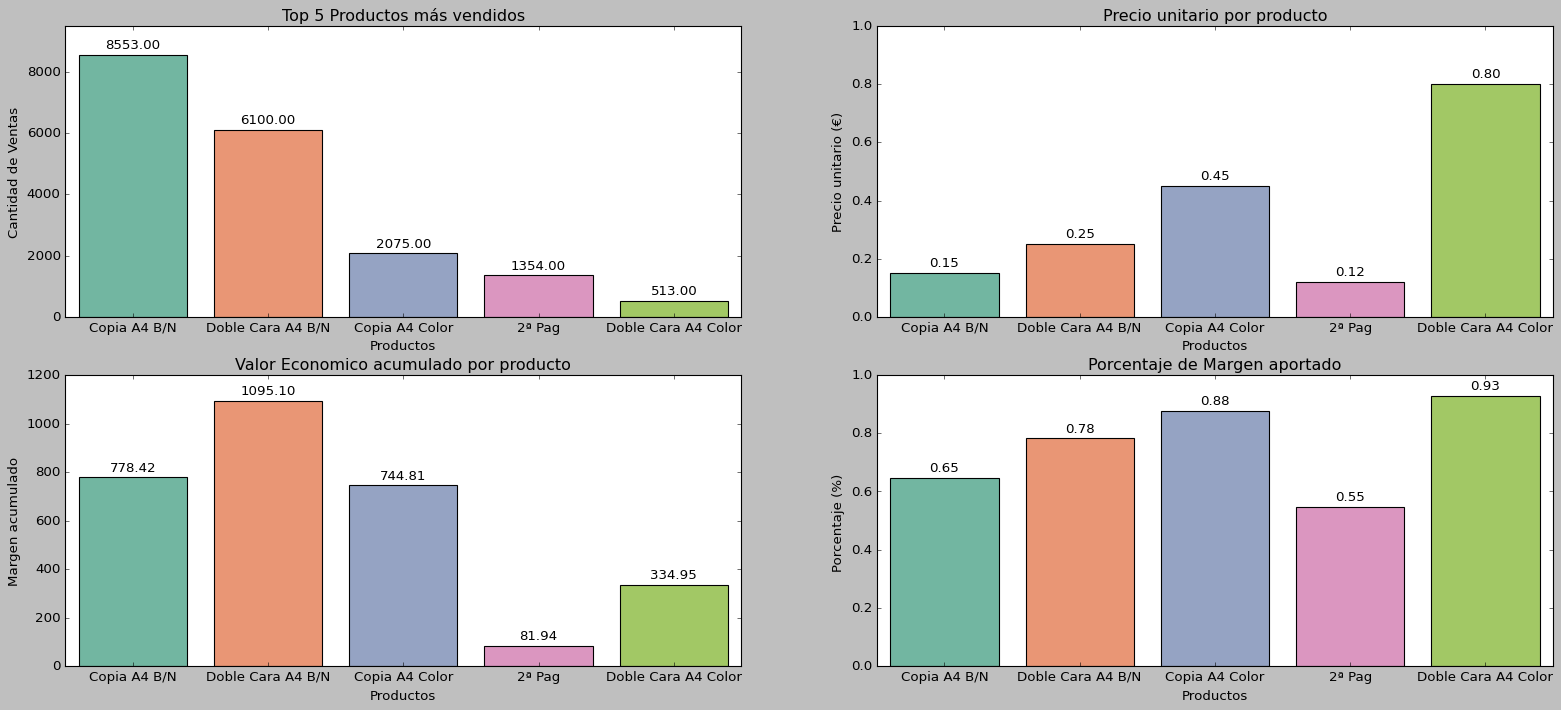

In [12]:
fig, ax=(plt.subplots(2,2, figsize=(24,10)))
sns.barplot(x="Name", y="Qty", data=top5, ax=ax[0,0], palette="Set2");
ax[0,0].set_title("Top 5 Productos más vendidos")
ax[0,0].set_xlabel("Productos")
ax[0,0].set_ylabel("Cantidad de Ventas")
ax[0,0].set_ylim(0,9500)
for c in ax[0,0].containers:
    ax[0,0].bar_label(c, fmt="%.2f", padding=3)


sns.barplot(x="Name", y="precio_unitario", data=top5, ax=ax[0,1], palette="Set2");
ax[0,1].set_title("Precio unitario por producto")
ax[0,1].set_xlabel("Productos")
ax[0,1].set_ylabel("Precio unitario (€)")
ax[0,1].set_ylim(0,1)
for c in ax[0,1].containers:
    ax[0,1].bar_label(c, fmt="%.2f", padding=3)


sns.barplot(x="Name", y="Margin", data=top5, ax=ax[1,0], palette="Set2");
ax[1,0].set_title("Valor Economico acumulado por producto")
ax[1,0].set_xlabel("Productos")
ax[1,0].set_ylabel("Margen acumulado")
for c in ax[1,0].containers:
    ax[1,0].bar_label(c, fmt="%.2f", padding=3)


sns.barplot(x="Name", y="MarginPerc", data=top5, ax=ax[1,1], palette="Set2");
ax[1,1].set_title("Porcentaje de Margen aportado")
ax[1,1].set_xlabel("Productos")
ax[1,1].set_ylabel("Porcentaje (%) ")
ax[1,1].set_ylim(0,1)
for c in ax[1,1].containers:
    ax[1,1].bar_label(c, fmt="%.2f", padding=3)

---

### 2. Los 5 productos menos vendidos (`bot5`)

Los 5 productos con **menor volumen de ventas** del catálogo. Se incluyen precio unitario, margen absoluto y margen porcentual real para comparar su eficiencia frente al `top5`.

**Resumen `bot5`**

| Campo | Descripción |
|---|---|
| `Qty` | 1 unidad vendida por producto (mínimo posible) |
| `precio_unitario` | Precio medio por unidad (€) |
| `Margin` | Margen absoluto total generado (€) |
| `MarginPerc_real` | Margen real = `Margin / ValueExcVat` |

> Nótese que el bajo margen absoluto de estos productos se explica principalmente por el escaso volumen, no necesariamente por un margen porcentual bajo.


/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21356/4253528255.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Name", x="Qty", data=bot5, ax=ax[0,0], palette="Set2");
/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21356/4253528255.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="precio_unitario", data=bot5, ax=ax[0,1], palette="Set2");
/var/folders/fr/6cwshw4x50bfxr_7_37z_lmm0000gp/T/ipykernel_21356/4253528255.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="Margin", data=bot5

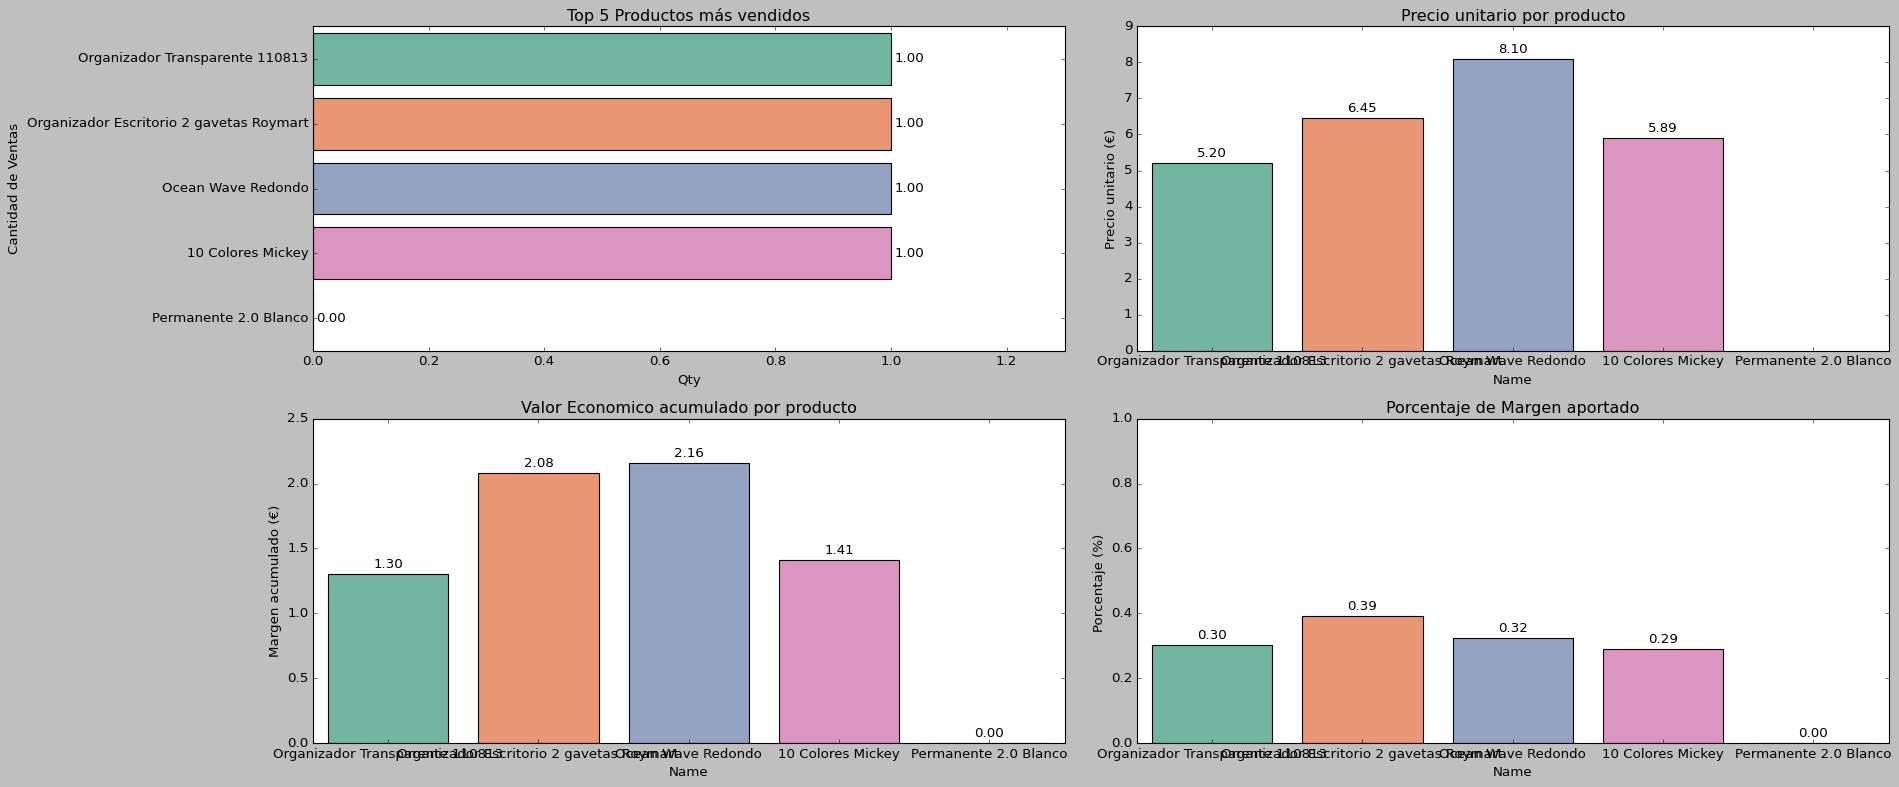

In [13]:
fig, ax=(plt.subplots(2,2, figsize=(24,10)))
sns.barplot(y="Name", x="Qty", data=bot5, ax=ax[0,0], palette="Set2");
ax[0,0].set_title("Top 5 Productos más vendidos")
ax[0,0].set_xlim(0,1.3)
for c in ax[0,0].containers:
    ax[0,0].bar_label(c, fmt="%.2f", padding=3)

ax[0,0].set_ylabel("Cantidad de Ventas")

sns.barplot(x="Name", y="precio_unitario", data=bot5, ax=ax[0,1], palette="Set2");
ax[0,1].set_title("Precio unitario por producto")
ax[0,1].set_ylabel("Precio unitario (€)")
for c in ax[0,1].containers:
    ax[0,1].bar_label(c, fmt="%.2f", padding=3)


sns.barplot(x="Name", y="Margin", data=bot5, ax=ax[1,0], palette="Set2");
ax[1,0].set_title("Valor Economico acumulado por producto")
ax[1,0].set_ylabel("Margen acumulado (€)")
for c in ax[1,0].containers:
    ax[1,0].bar_label(c, fmt="%.2f", padding=3)


sns.barplot(x="Name", y="MarginPerc", data=bot5, ax=ax[1,1], palette="Set2");
ax[1,1].set_title("Porcentaje de Margen aportado")
ax[1,1].set_ylabel("Porcentaje (%) ")
ax[1,1].set_ylim(0,1)
for c in ax[1,1].containers:
    ax[1,1].bar_label(c, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()

---

### 3. ¿Cuánto representa el Top 5 sobre el total del negocio?

Se calcula el peso del `top5` sobre el total del catálogo en dos dimensiones:

- **Margen absoluto (€):** cuántos euros de margen generan los 5 productos más vendidos respecto al margen total
- **Volumen (Qty):** qué proporción de las unidades totales vendidas concentran estos 5 productos

**Variables utilizadas**

| Variable | Descripción |
|---|---|
| `margen_total` | Suma de `Margin` sobre `h1_agrupados` |
| `media_marginperc` | `Margin.sum() / ValueExcVat.sum()` — margen % real medio del catálogo |
| `Total` | Suma de `Value` sobre `df1` — valor bruto total de ventas |


In [14]:
Total=df1.Value.sum()


In [15]:
top5

,Name,Qty,Value,Discount,ValueIncVat,ValueExcVat,Costo,Margin,MarginPerc,MarginPerc_real,precio_unitario
239,Copia A4 B/N,8553,1282.95,1.92,1281.03,1206.07,427.65,778.42,0.64542,0.645419,0.15
275,Doble Cara A4 B/N,6100,1525.00,14.94,1510.06,1400.10,305.00,1095.10,0.78216,0.782158,0.25
240,Copia A4 Color,2075,933.75,33.15,900.60,848.56,103.75,744.81,0.87773,0.877734,0.45
10,2ª Pag,1354,162.48,0.00,162.48,149.64,67.70,81.94,0.54758,0.547581,0.12
276,Doble Cara A4 Color,513,410.40,14.74,395.66,360.60,25.65,334.95,0.92887,0.928869,0.80


In [16]:
margen_total = h1_agrupados.Margin.sum()
media_marginperc = (h1_agrupados.Margin.sum() / h1_agrupados.ValueExcVat.sum())


---

### 4. Comparativa Top 5 vs Bottom 5

Se confrontan directamente los dos grupos en las dos métricas clave de la hipótesis:

| Dimensión | ¿Qué mide? |
|---|---|
| **Margen absoluto (€)** | Cuántos euros de margen aporta cada producto al negocio |
| **Margen porcentual real (%)** | Eficiencia del margen = `Margin / ValueExcVat` |

> El margen porcentual real corrige el `MarginPerc` original del dataset, que al estar sumado por filas no es comparable entre productos con distinto volumen.


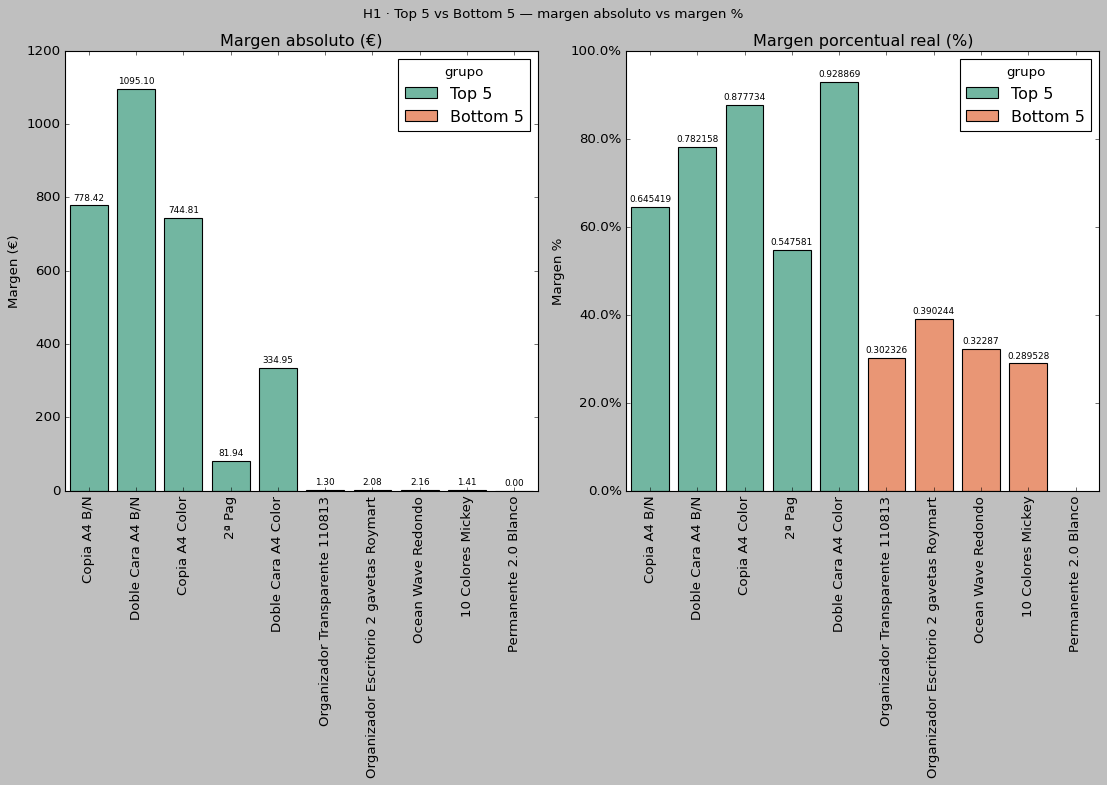

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 10))
fig.suptitle("H1 · Top 5 vs Bottom 5 — margen absoluto vs margen %")


top5["grupo"] = "Top 5"
bot5["grupo"] = "Bottom 5"
comparativa = pd.concat([top5, bot5])

# Margen absoluto
sns.barplot(data=comparativa, x="Name", y="Margin", hue="grupo", palette="Set2", ax=ax[0])
ax[0].set_title("Margen absoluto (€)")
ax[0].set_xlabel("")
ax[0].set_ylabel("Margen (€)")
ax[0].tick_params(axis="x", rotation=90)
for c in ax[0].containers:
    ax[0].bar_label(c, fmt="%.2f", padding=3, fontsize=8)

# Margen porcentual real
sns.barplot(data=comparativa, x="Name", y="MarginPerc_real", hue="grupo", palette="Set2", ax=ax[1])
ax[1].set_title("Margen porcentual real (%)")
ax[1].set_xlabel("")
ax[1].set_ylabel("Margen %")
ax[1].tick_params(axis="x", rotation=90)
ax[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
for c in ax[1].containers:
    ax[1].bar_label(c, padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("h1_comparativa_margen.png", dpi=150, bbox_inches="tight")
plt.show()

---

### 5. Conclusión




Text(0.5, 1.0, '% de unidades vendidas (Qty)')

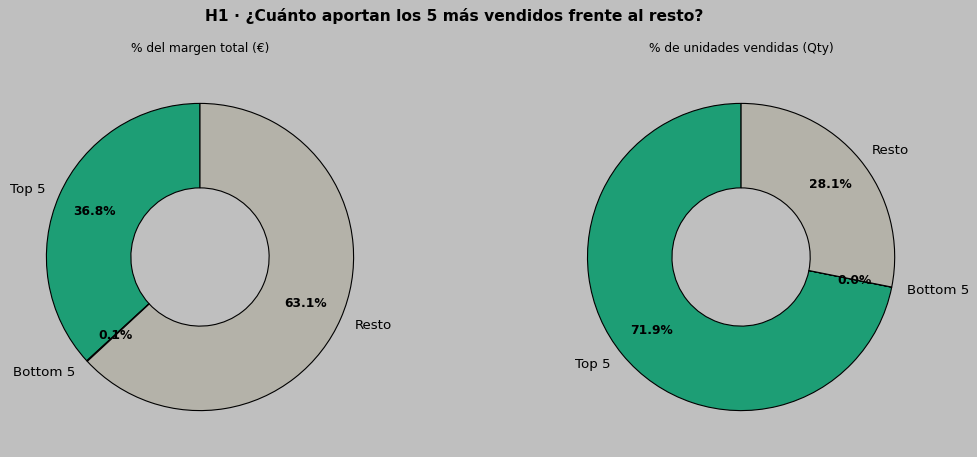

In [21]:
# ── Celda nueva: ¿Cuánto representa el Top5 sobre el total? ──────────────────

margen_top5   = top5["Margin"].sum()
margen_bot5   = bot5["Margin"].sum()
margen_resto  = margen_total - margen_top5 - margen_bot5

pct_top5  = margen_top5  / margen_total * 100
pct_bot5  = margen_bot5  / margen_total * 100
pct_resto = margen_resto / margen_total * 100

qty_top5  = top5["Qty"].sum()
qty_bot5  = bot5["Qty"].sum()
qty_total = h1_agrupados["Qty"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("H1 · ¿Cuánto aportan los 5 más vendidos frente al resto?",
             fontsize=14, fontweight="bold", y=1.02)

COLOR_TOP   = "#1D9E75"
COLOR_BOT   = "#D85A30"
COLOR_RESTO = "#B4B2A9"

# ── Donut 1: % margen sobre el total ─────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    [pct_top5, pct_bot5, pct_resto],
    labels=["Top 5", "Bottom 5", "Resto"],
    colors=[COLOR_TOP, COLOR_BOT, COLOR_RESTO],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55),   # donut
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
axes[0].set_title("% del margen total (€)", fontsize=11, pad=12)

# ── Donut 2: % unidades sobre el total ────────────────────────────────────────
pct_qty_top5  = qty_top5  / qty_total * 100
pct_qty_bot5  = qty_bot5  / qty_total * 100
pct_qty_resto = (qty_total - qty_top5 - qty_bot5) / qty_total * 100

wedges2, texts2, autotexts2 = axes[1].pie(
    [pct_qty_top5, pct_qty_bot5, pct_qty_resto],
    labels=["Top 5", "Bottom 5", "Resto"],
    colors=[COLOR_TOP, COLOR_BOT, COLOR_RESTO],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55),
    pctdistance=0.75,
)
for at in autotexts2:
    at.set_fontsize(11)
    at.set_fontweight("bold")
axes[1].set_title("% de unidades vendidas (Qty)", fontsize=11, pad=12)


In [22]:
print("Respuesta Hipotesis 1")
print(f"  Margen total negocio:               €{margen_total:,.2f}")
print(f"  Margen % medio del negocio:          {media_marginperc*100:.1f}%")
print()
print(f"  Top 5 margen absoluto:              €{top5['Margin'].sum():,.2f}  "
      f"({top5['Margin'].sum()/margen_total*100:.1f}% del total)")
print(f"  Top 5 margen % real medio:           "
      f"{top5['MarginPerc_real'].mean()*100:.1f}%  "
      f"({'por encima' if top5['MarginPerc_real'].mean() > media_marginperc else 'por debajo'} "
      f"de la media)")
print()
print(f"  Bottom 5.  margen absoluto:         €{bot5['Margin'].sum():,.2f}  "
      f"({bot5['Margin'].sum()/margen_total*100:.1f}% del total)")
print(f"  Bottom 5.  margen % real medio:      "
      f"{bot5['MarginPerc_real'].mean()*100:.1f}%  "
      f"({'por encima' if bot5['MarginPerc_real'].mean() > media_marginperc else 'por debajo'} "
      f"de la media)")


Respuesta Hipotesis 1
  Margen total negocio:               €8,246.43
  Margen % medio del negocio:          56.0%

  Top 5 margen absoluto:              €3,035.22  (36.8% del total)
  Top 5 margen % real medio:           75.6%  (por encima de la media)

  Bottom 5.  margen absoluto:         €6.95  (0.1% del total)
  Bottom 5.  margen % real medio:      32.6%  (por debajo de la media)


Se evalúa la hipótesis en dos dimensiones independientes para obtener una respuesta simplificada:

| Dimensión | Resultado | Interpretación |
|---|---|---|
| Margen absoluto (€) | Verdadera | El Top 5 concentra la mayor parte del margen total en euros |
| Margen porcentual real (%) |  Revisar con datos | Comparar el % medio del Top 5 con la media del catálogo |


